# TESTING PYMC

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

In [2]:
print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.28.4


In [3]:
# Enable high-resolution plot rendering for sharp visuals
%config InlineBackend.figure_format = 'retina'

# Define a seed to ensure random results are reproducible
RANDOM_SEED = 8927
# Initialize the modern NumPy random number generator
rng = np.random.default_rng(RANDOM_SEED)

# Apply a clean, dark-grid visual theme to all ArviZ/Matplotlib plots
az.style.use("arviz-darkgrid")

### pyMC TEMPLATE

```python
import pymc as pm
import arviz as az
import numpy as np

# 1. Setup Data
# These would be your actual data arrays
X_data = np.random.randn(100)
Y_data = 2.5 * X_data + np.random.normal(0, 1, size=100)

# 2. Define the Model
# Using 'with' creates a context manager that adds variables to this specific model
with pm.Model() as generic_model:
    
    # --- PRIORS ---
    # Your 'initial guesses' about the parameters
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    slope = pm.Normal("slope", mu=0, sigma=10)
    
    # Standard deviation must be positive, hence HalfNormal or Exponential
    sigma = pm.HalfNormal("sigma", sigma=1)
    
    # --- DETERMINISTIC STEP ---
    # The mathematical formula linking predictors to the outcome
    # mu is a 'deterministic' variable because it is a direct calculation
    mu = pm.Deterministic("mu", intercept + slope * X_data)
    
    # --- LIKELIHOOD ---
    # The 'observed' argument tells PyMC this is where the data enters the model
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y_data)
    
    # 3. INFERENCE (Sampling)
    # 'pm.sample' returns an InferenceData object (assigned to idata), which is a structured container (based on xarray) that holds the samples, the original data, and metadata about how the sampler performed.
    # draws: number of samples to keep
    # tune: 'warm-up' steps to help the sampler find the right space
    # chains: independent runs to ensure consistency
    trace = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

# 4. ANALYSIS & VISUALIZATION
# Plot the 'forest' of distributions for your parameters
az.plot_trace(trace)

# Summary table: look for r_hat close to 1.00 (indicates convergence)
summary = az.summary(trace, round_to=2)        # 'round_to' simply controls the digits output
print(summary)
```

### EXAMPLE: LINEAR REGRESSION

We are interested in predicting outcomes $Y$ as normally-distributed observations with an expected value $\mu$ that is a linear function of two predictor variables, $X_1$ and $X_2$:

$$Y \sim \mathcal{N}(\mu, \sigma^2)$$

$$\mu = \alpha + \beta_1 X_1 + \beta_2 X_2$$

where $\alpha$ is the intercept, $\beta_i$ is the coefficient for covariate $X_i$, and $\sigma$ represents the observation error. 

Since we are constructing a Bayesian model, we must assign a prior distribution to the unknown variables. We choose zero-mean normal priors with a variance of 100 for the regression coefficients, providing weak information regarding the true parameter values. We use a half-normal distribution (normal distribution bounded at zero) as the prior for $\sigma$:

$$\alpha \sim \mathcal{N}(0, 100)$$

$$\beta_i \sim \mathcal{N}(0, 100)$$

$$\sigma \sim \text{HalfNormal}(1) \quad \text{or} \quad \sigma \sim |\mathcal{N}(0, 1)|$$

### CREATING DATASET

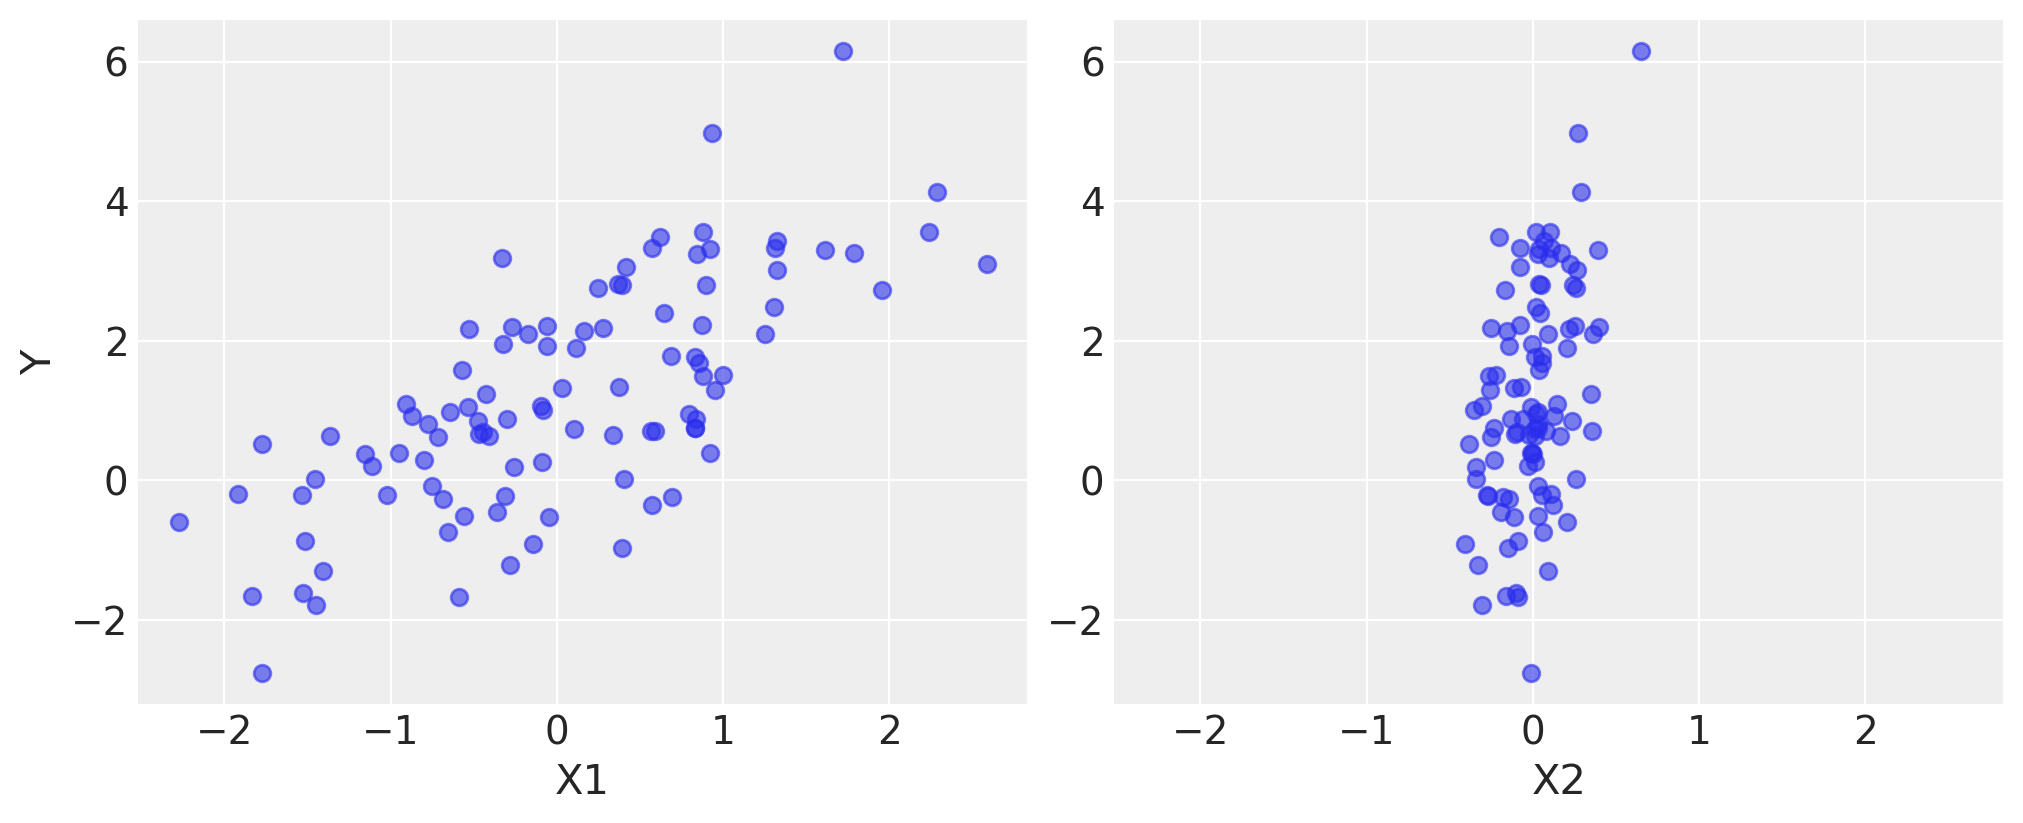

In [4]:
# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + rng.normal(size=size) * sigma

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X1, Y, alpha=0.6)
axes[1].scatter(X2, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X1")
axes[1].set_xlabel("X2")
plt.show()

In [5]:
basic_model = pm.Model()

with basic_model:

    """ --- PRIORS ---
    Priors for unknown model parameters
    The first argument is always the name of the random variable, which should almost always match the name of the Python variable being
    assigned to, since it is sometimes used to retrieve the variable from the model for summarizing output. 
    """
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # The 'shape' argument is available for all distributions and specifies the length or shape of the random variable, but is optional
    # for scalar variables, since it defaults to a value of one. It can be an integer to specify an array, or a tuple to specify
    # a multidimensional array (e.g. shape=(5,7) makes a random variable that takes on 5 by 7 matrix values)

    """ --- DETERMINISTIC ---
    Expected value of outcome
    This creates a deterministic random variable, which implies that its value is completely determined by its parents’ values
    Instead of 'pm.Deterministic', you could also use the simple python variable mu. The difference is that using mu
    you discard that variable after each sample (saving memory); using Deterministic you save it and you can then observe it in the trace
    """
    mu = alpha + beta[0] * X1 + beta[1] * X2


    """ --- LIKELIHOOD ---
    The 'observed' argument tells PyMC this is where the data enters the model
    This is a special case of a stochastic variable that we call an observed stochastic, and represents the data likelihood of the model.
    It is identical to a standard stochastic, except that its observed argument, which passes the data to the variable, 
    indicates that the values for this variable were observed, and should not be changed by any fitting algorithm applied to the model
    """
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)


    

    """ --- SAMPLING PHASE ---
    Draw 1000 posterior samples
    Notice that sample generated a set of parallel chains, depending on how many compute cores are on your machine.
    """
    idata = pm.sample(draws=1000)

    # The various attributes of the InferenceData object can be queried in a similar way to a dict containing a map from variable names to
    # numpy.arrays. For example, we can retrieve the sampling trace from the alpha latent variable by using the variable name as an index
    # to the idata.posterior attribute. The first dimension of the returned array is the chain index, the second dimension is the sampling 
    # index, while the later dimensions match the shape of the variable. We can see the first 5 values for the alpha variable in each chain
    # as follows:
    idata.posterior["alpha"].sel(draw=slice(0, 4))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]
/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


How to interpret the output of pyMC:
* **`Initializing NUTS using jitter+adapt_diag...`**: This is the setup phase. PyMC adds a bit of "jitter" (random noise) to the starting points and "adapt_diag" (scales the step sizes) so the sampler doesn't get stuck in one spot right at the beginning.
* **`Multiprocess sampling (4 chains in 4 jobs)`**: PyMC is running 4 independent simulations ("chains") simultaneously using 4 CPU cores. Running multiple chains is vital to ensure that different "hikers" all find the same "mountain peak."
* **`NUTS: [alpha, beta, sigma]`**: This confirms that the No-U-Turn Sampler is being used to estimate these specific parameters from your model.
* **`RuntimeWarning: overflow encountered in dot`**: This is a yellow flag. It means that during the math calculations, some numbers got too large for the computer to handle (likely during the initialization or "tuning" phase). While common, if it persists, it could mean your **priors** are too wide or your data needs scaling.
* **`Draw` (2000)**: The total number of steps taken per chain. This includes 1,000 "tuning" steps (to learn the landscape) and 1,000 "draws" (the actual samples you keep).
* **`Divergences` (0)**: **The most important number.** A divergence is a "math glitch" where the sampler loses its way because the geometry is too steep. Since this is **0**, your results are likely very reliable.
* **`Step size`**: How large the sampler's "stride" was. NUTS adjusts this automatically; if it's too small, sampling is slow; if it's too large, it might crash (diverge).
* **`Grad evals`**: The number of times the sampler calculated the "slope" (gradient) of your distribution (i.e. the number of leapfrog steps). A value of 3 is remarkably low and efficient. It means the "surface" of your posterior is very smooth and easy to navigate.
* **`Speed / Elapsed`**: Statistical performance metrics showing how fast the C++ or JAX backend crunched the numbers.

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.16,0.11,0.96,1.35,0.00,0.00,6265.65,3277.07,1.0
beta[0],1.03,0.10,0.83,1.23,0.00,0.00,6112.48,3433.28,1.0
beta[1],2.71,0.54,1.75,3.74,0.01,0.01,5866.43,3432.81,1.0
sigma,1.01,0.07,0.88,1.15,0.00,0.00,4915.12,3253.35,1.0


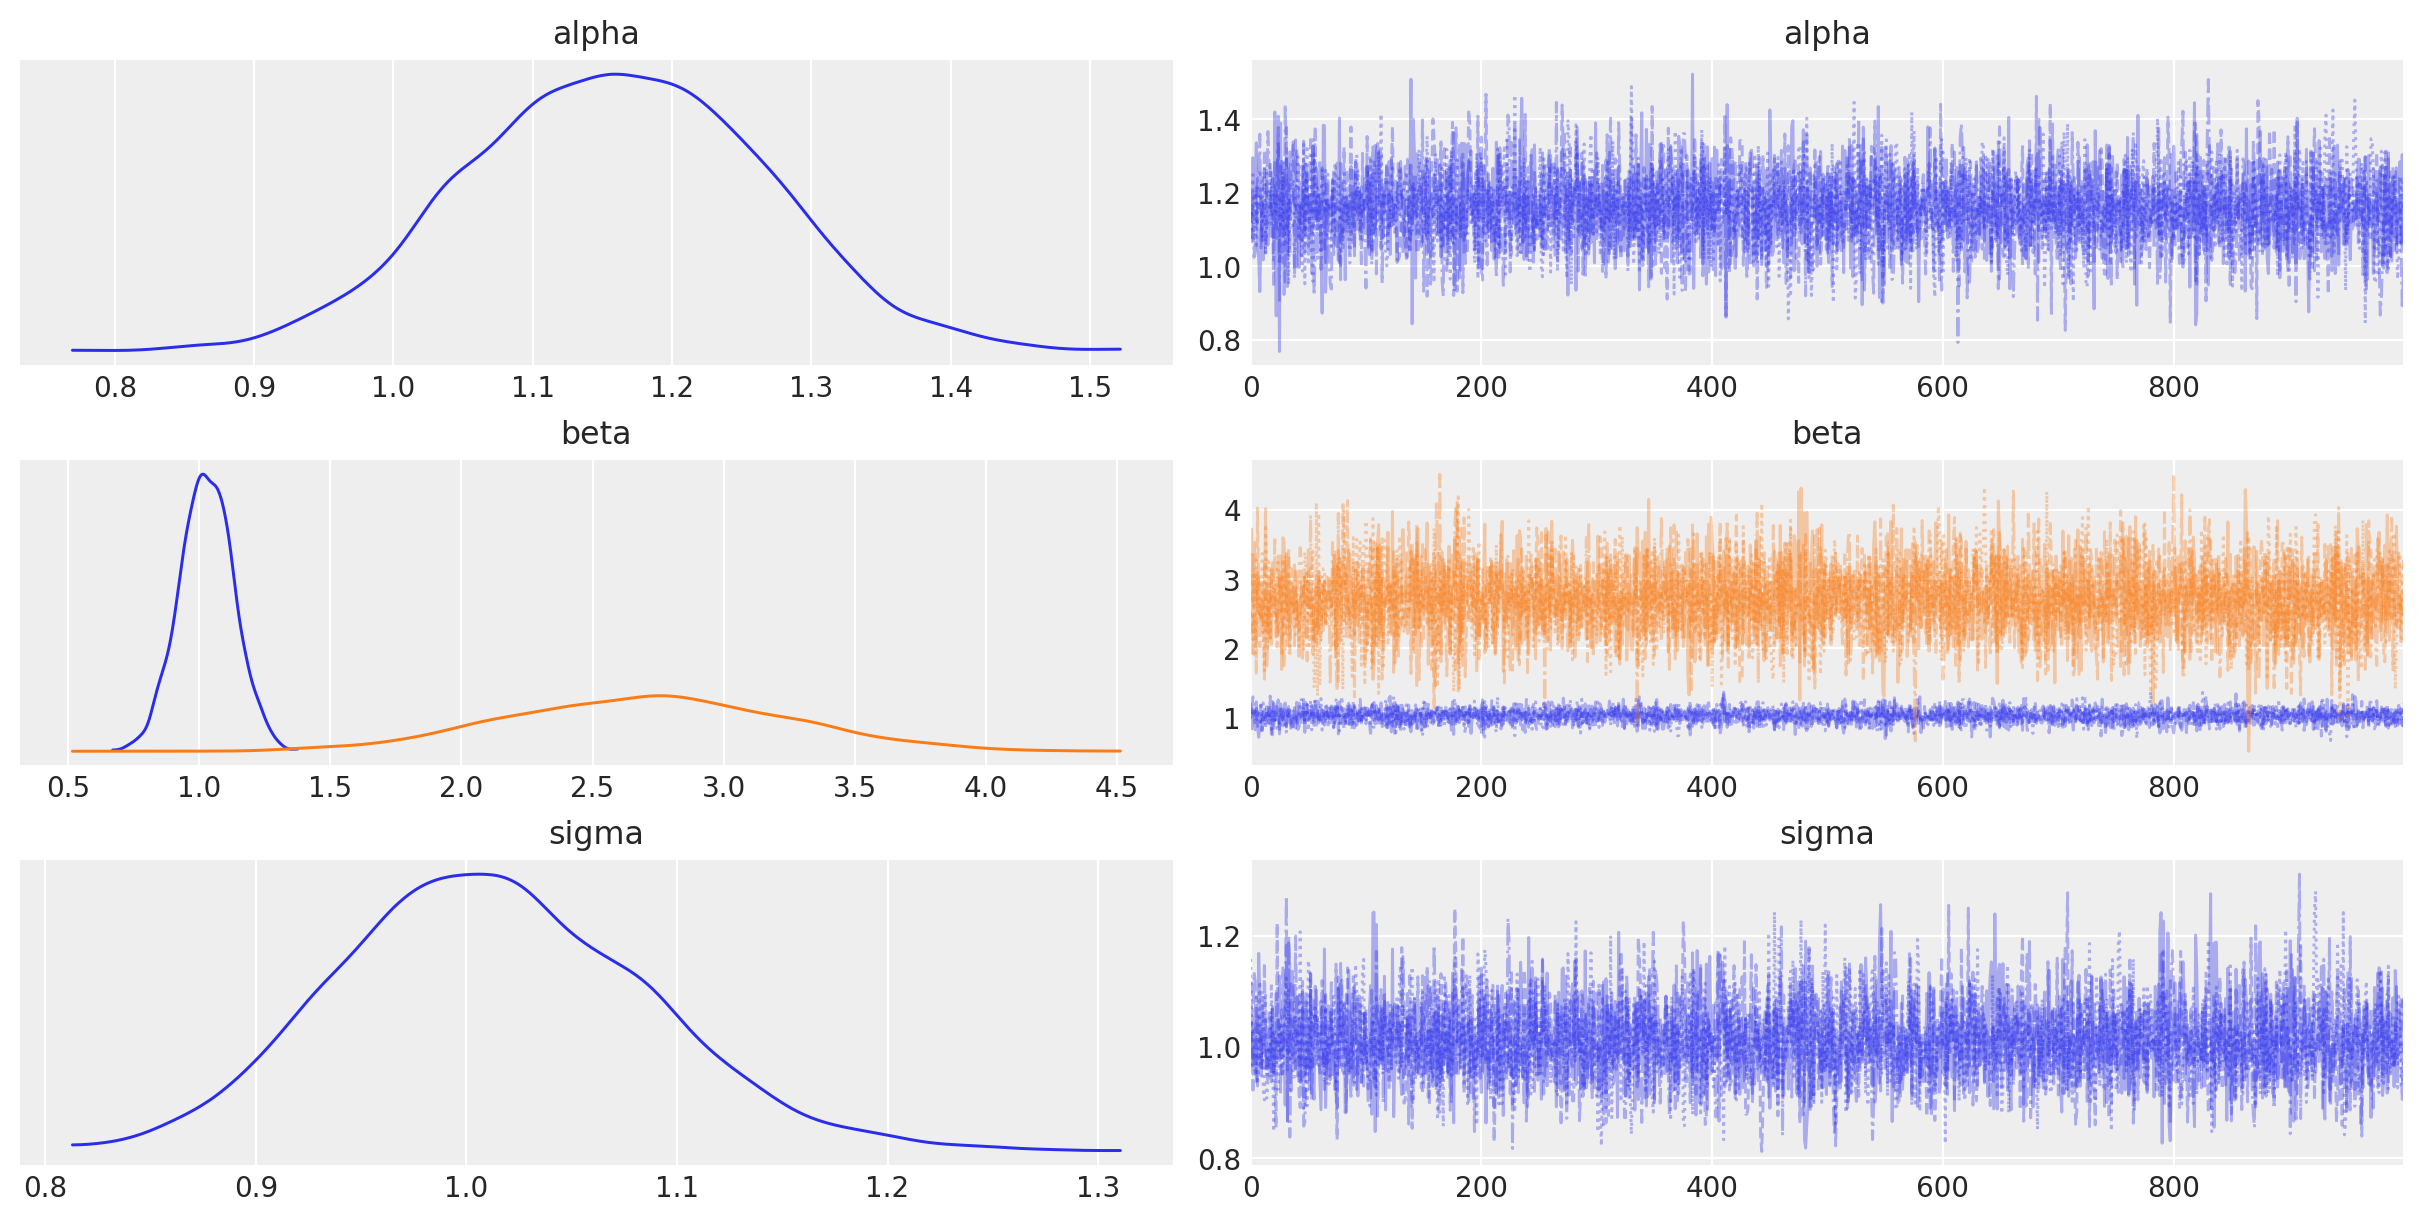

In [6]:
az.plot_trace(idata, combined=True)
# The left column consists of a smoothed histogram (using kernel density estimation) of the marginal posteriors of each stochastic
# random variable while the right column contains the samples of the Markov chain plotted in sequential order. The beta variable, 
# being vector-valued, produces two density plots and two trace plots, corresponding to both predictor coefficients.

az.summary(idata, round_to=2)

---

---

---

---

### EXAMPLE: POISSON

The occurrences of disasters in the time series are thought to follow a **Poisson process** with a large rate parameter in the early part of the time series, and one with a smaller rate in the later part. We are interested in locating the **change point** in the series, which may be related to changes in mining safety regulations.

The statistical structure is defined as follows:

$$D_t \sim \text{Poisson}(r_t)$$

The rate parameter $r_t$ is defined by a switchpoint $s$:

$$
r_t = 
\begin{cases} 
e & \text{if } t \le s \\
l & \text{if } t > s 
\end{cases}
$$

The priors for the unknown parameters are:

$$s \sim \text{DiscreteUniform}(t_l, t_h)$$
$$e \sim \text{Exponential}(1)$$
$$l \sim \text{Exponential}(1)$$

where:

* **$D_t$**: The number of disasters observed in year $t$.
* **$r_t$**: The rate parameter of the Poisson distribution in year $t$.
* **$s$**: The year in which the rate parameter changes (the **switchpoint**).
* **$e$**: The "early" rate parameter (before the switchpoint $s$).
* **$l$**: The "late" rate parameter (after the switchpoint $s$).
* **$t_l, t_h$**: The lower and upper boundaries of the time period under observation.

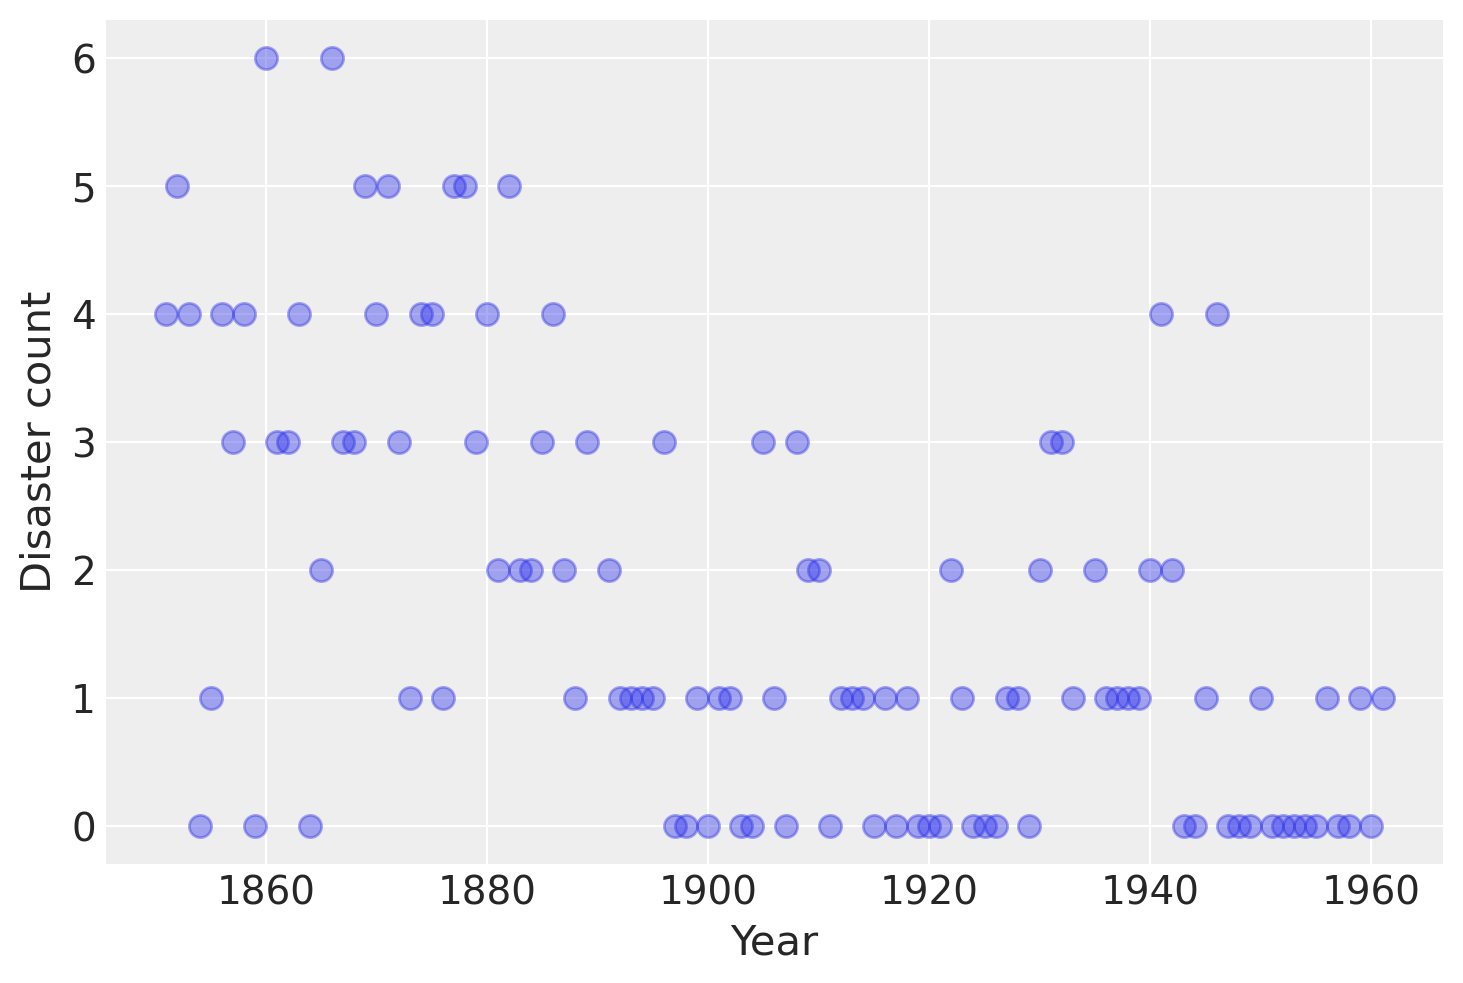

In [7]:
# fmt: off
disaster_data = pd.Series(
    [4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
    3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
    2, 2, 3, 4, 2, 1, 3, np.nan, 2, 1, 1, 1, 1, 3, 0, 0,   # PyMC is actually capable of handling missing data automatically
    1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
    0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
    3, 3, 1, np.nan, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
    0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1]
)
# fmt: on
years = np.arange(1851, 1962)

plt.plot(years, disaster_data, "o", markersize=8, alpha=0.4)
plt.ylabel("Disaster count")
plt.xlabel("Year");

In [8]:
with pm.Model() as disaster_model:
    switchpoint = pm.DiscreteUniform("switchpoint", lower=years.min(), upper=years.max())

    # Priors for pre- and post-switch rates number of disasters
    early_rate = pm.Exponential("early_rate", 1.0)
    late_rate = pm.Exponential("late_rate", 1.0)

    # Allocate appropriate Poisson rates to years before and after current
    rate = pm.math.switch(switchpoint >= years, early_rate, late_rate)   
    # This is the PyMC version of an if-else statement. 
    # This creates a vector of rates (one for each year) that looks like a step function.

    # LIKELIHOOD    
    disasters = pm.Poisson("disasters", rate, observed=disaster_data)

with disaster_model:
    # https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample.html
    idata = pm.sample(10000, chains=4, cores=4)

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/model/core.py:1302: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/model/core.py:1316: ImputationWarning: Data in disasters contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>Metropolis: [switchpoint]
>>Metropolis: [disasters_unobserved]
>NUTS: [early_rate, late_rate]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 6 seconds.


Notice that PyMC didn't just use one algorithm. It used a **CompoundStep**, which is like a team of specialists:
* **`Metropolis: [switchpoint]`**: Because the `switchpoint` is a **discrete integer** (year 1890, 1891, etc.), it has no "slope" or gradient. NUTS cannot work here. PyMC falls back to the simpler **Metropolis-Hastings** algorithm, which jumps around randomly to see if the fit improves.
* **`Metropolis: [disasters_unobserved]`**: This is the "Imputation" mentioned above. It is using Metropolis to guess the specific values for the `np.nan` spots in your data.
* **`NUTS: [early_rate, late_rate]`**: These are continuous variables, so the high-performance NUTS engine handles them, gliding through the probability space efficiently.

The Performance Table
* **`Accept Rate`**: Look at these numbers (0.03, 0.01, 0.51, 0.05). In a NUTS-only model, we want this near **0.80**. However, because you are using **Metropolis** for the switchpoint, lower acceptance rates are common and expected. Metropolis is "pickier" and rejects more jumps.
* **`Grad evals` (1 to 3)**: Still very low, meaning the continuous parts of your model (`early_rate` and `late_rate`) are extremely easy for the sampler to map out.
* **`Speed`**: ~1800 draws/s. This is slower than your previous model (which was ~3000 draws/s). This "speed penalty" happens because Metropolis is less efficient than NUTS and the model has to juggle the imputed missing values.

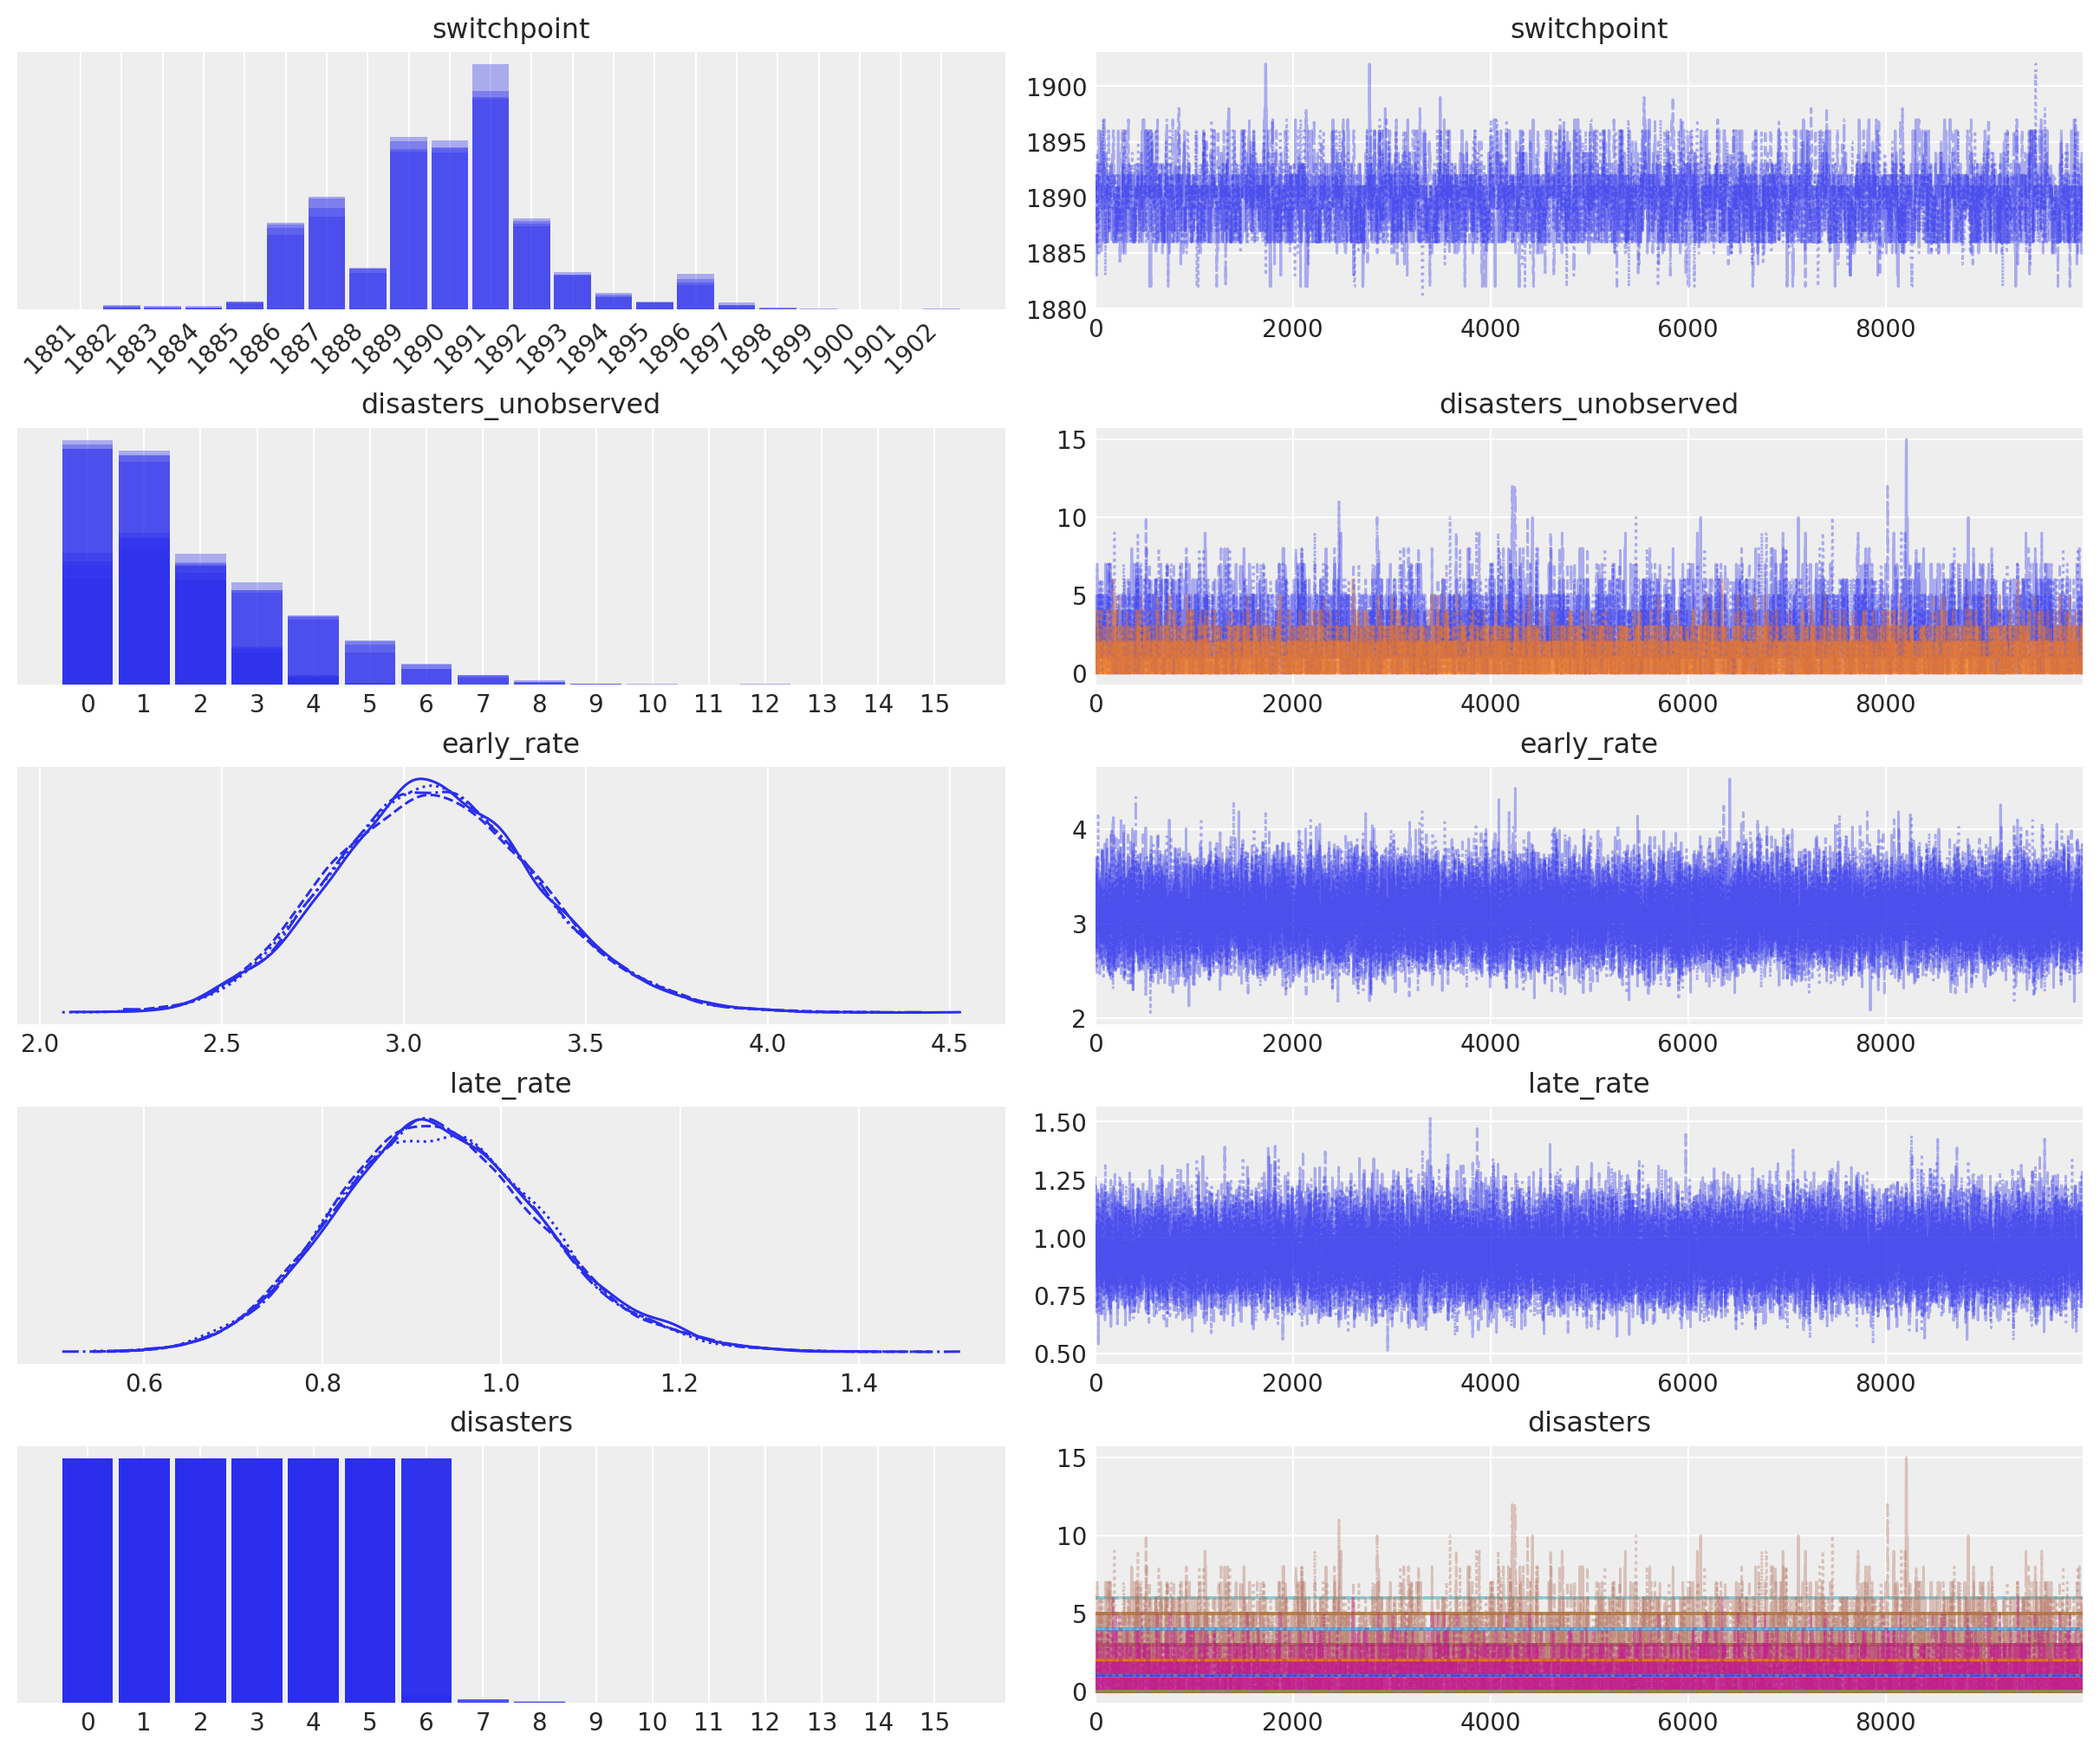

In [10]:
# --- PART 1: Diagnostic Plots ---
# Create trace plots (distributions on left, sample paths on right)
axes_arr = az.plot_trace(idata)
plt.draw()

# Iterate through the subplots to fix the 'switchpoint' x-axis labels
for ax in axes_arr.flatten():
    if ax.get_title() == "switchpoint":
        labels = [label.get_text() for label in ax.get_xticklabels()]
        # Rotate labels for readability
        ax.set_xticklabels(labels, rotation=45, ha="right")
        break
plt.draw()

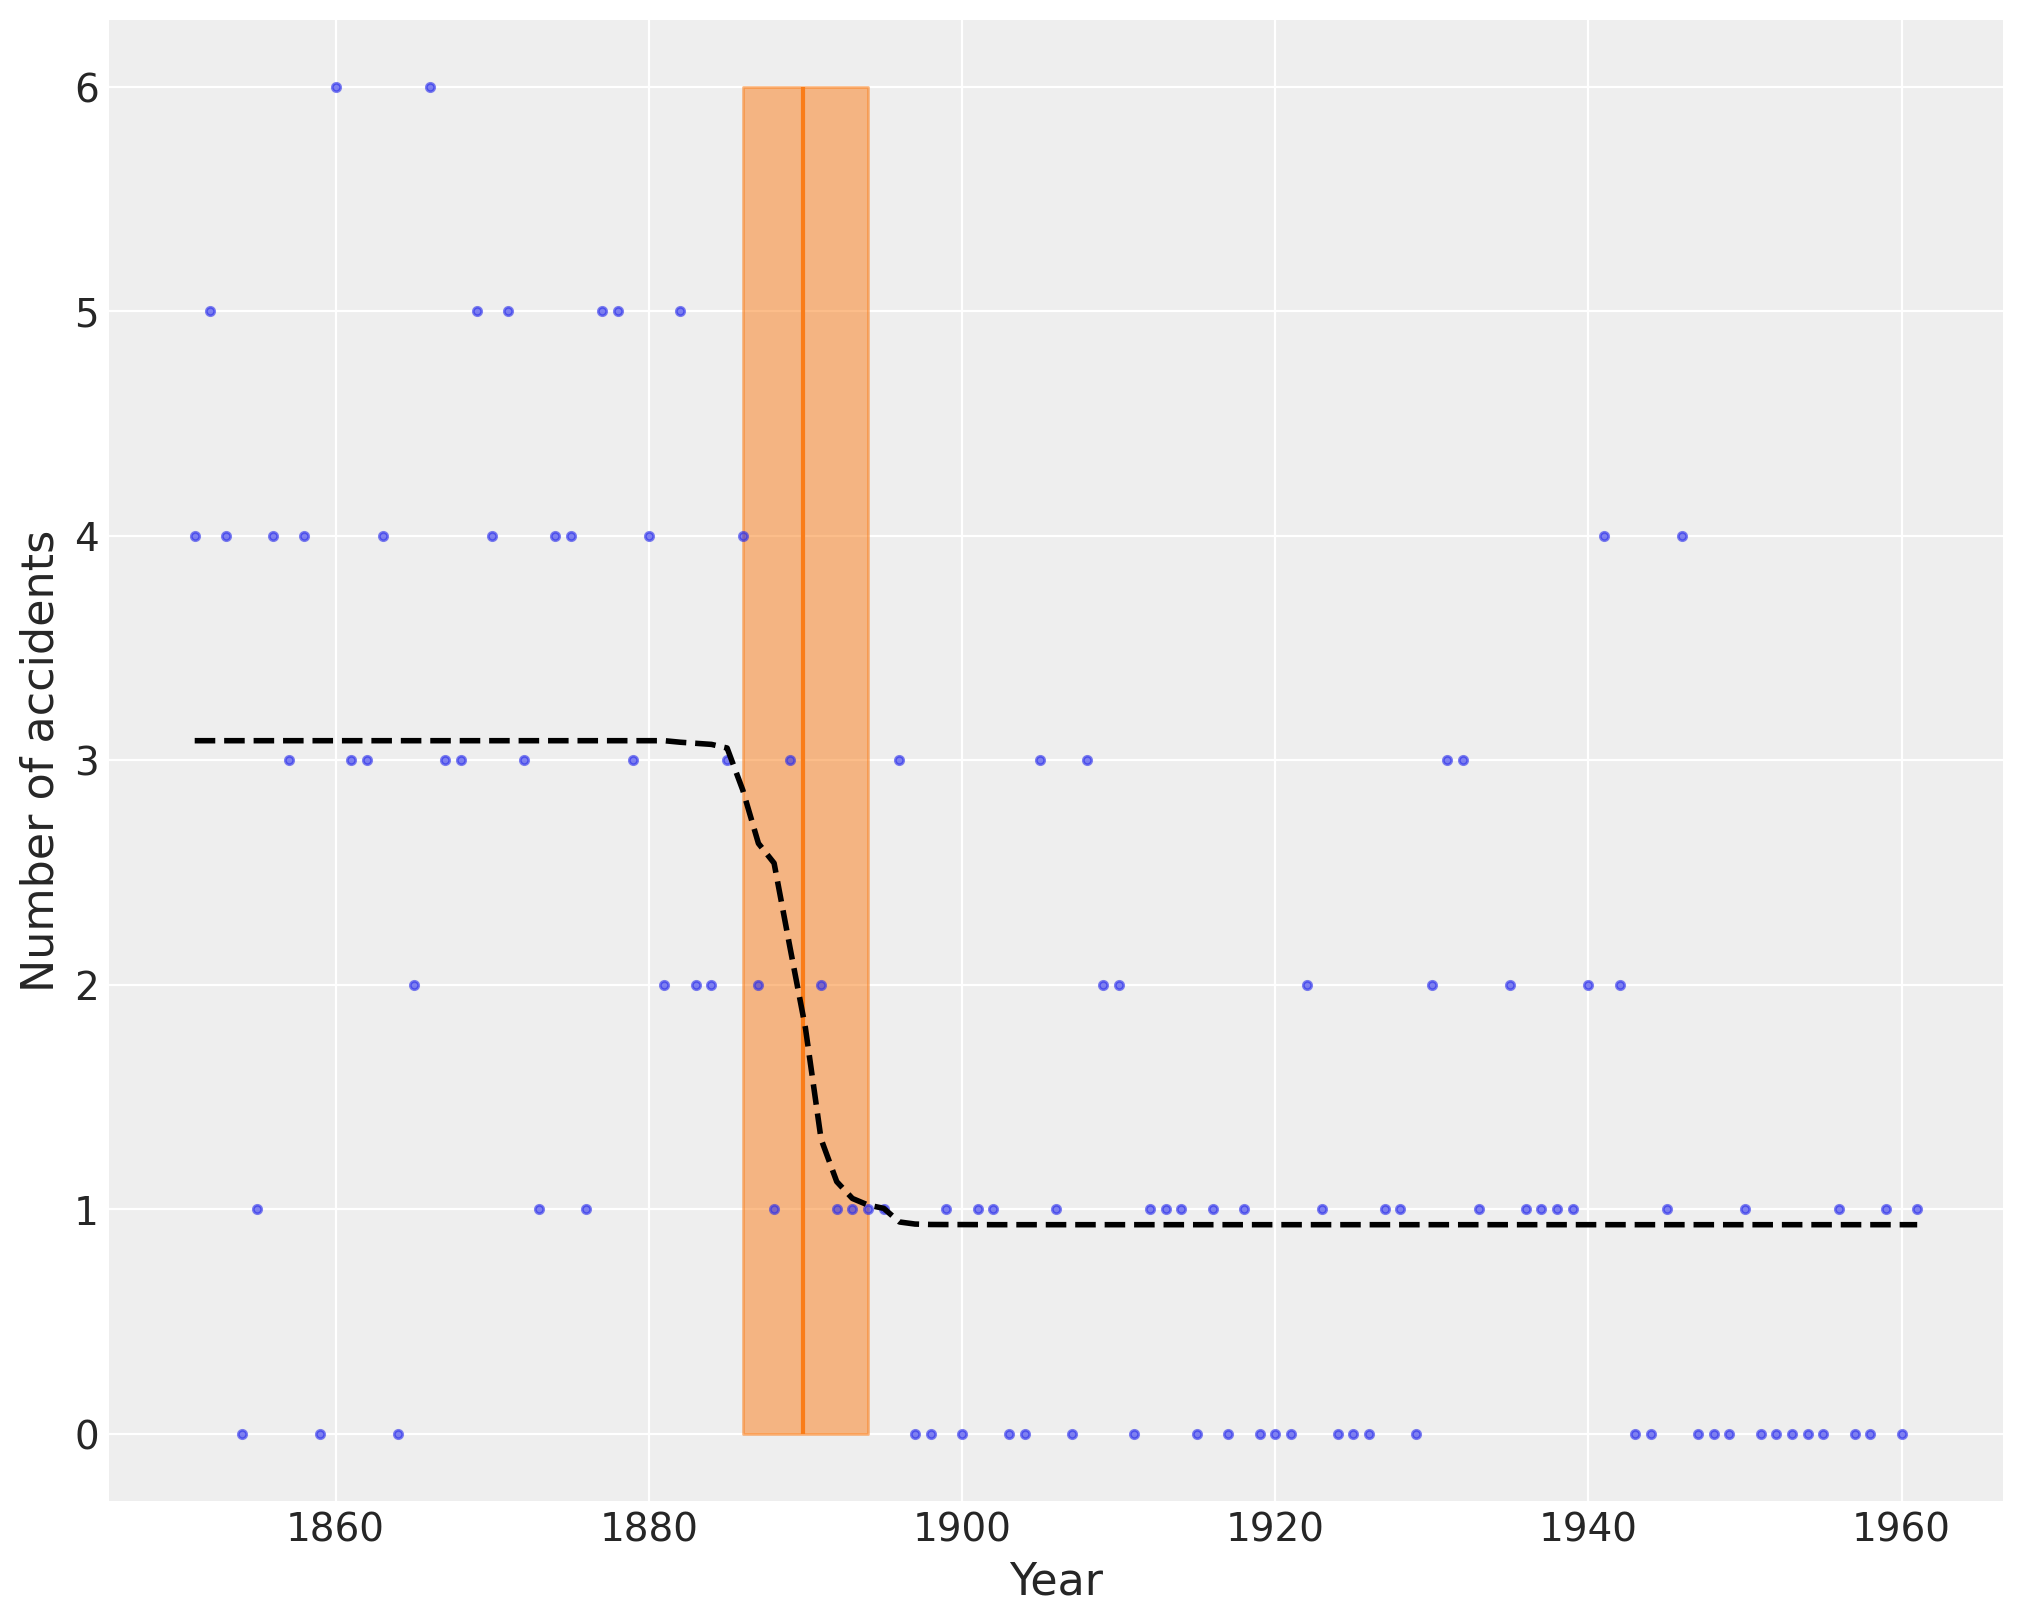

In [11]:
# --- PART 2: Overlaying Model on Data ---
plt.figure(figsize=(10, 8))
# Plot the raw disaster counts as semi-transparent dots
plt.plot(years, disaster_data, ".", alpha=0.6)
plt.ylabel("Number of accidents", fontsize=16)
plt.xlabel("Year", fontsize=16)

# Flatten the chains and draws into one single dimension for easier calculation
trace = idata.posterior.stack(draws=("chain", "draw"))

# Draw a vertical line at the mean switchpoint year
plt.vlines(trace["switchpoint"].mean(), disaster_data.min(), disaster_data.max(), color="C1")

# Calculate the 'expected' number of disasters per year averaged over all posterior samples
average_disasters = np.zeros_like(disaster_data, dtype="float")
for i, year in enumerate(years):
    # For this year, which samples say we are in the 'early' period?
    idx = year < trace["switchpoint"]
    # Average the rates (early vs late) based on those samples
    average_disasters[i] = np.mean(np.where(idx, trace["early_rate"], trace["late_rate"]))

# Calculate the 94% Highest Density Interval (the 'credible range') for the switchpoint
sp_hpd = az.hdi(idata, var_names=["switchpoint"])["switchpoint"].values

# Shade the area representing the uncertainty of when the switch happened
plt.fill_betweenx(
    y=[disaster_data.min(), disaster_data.max()],
    x1=sp_hpd[0],
    x2=sp_hpd[1],
    alpha=0.5,
    color="C1",
)

# Plot the black dashed line representing the 'mean' model fit
plt.plot(years, average_disasters, "k--", lw=2)
plt.show()